# 第 08 章　K-平均分群（K-Means Clustering）

本 notebook 搭配網站「醫學生的機器學習入門」第 08 章。建議在 Google Colab 開啟：上方選單「執行階段 → 全部執行」即可從頭跑完（約 1 分鐘，不需要 GPU）。

這一章是本課程第一個**非監督學習（unsupervised learning）**：資料沒有答案欄位，我們要讓演算法自己找出「哪些病人彼此比較像」。

流程：
1. 用 2D 玩具資料，徒手寫出 K-Means 的四個步驟
2. 用 scikit-learn 的 `KMeans` 重做一次
3. 用 Heart Failure Clinical Records 資料，把心衰竭病人分群，再**事後**比較各群死亡比例
4. 看 K-Means 會在哪裡失敗

> 圖上的標籤用英文，是因為 Colab 預設沒有中文字型（中文會變成方塊）。

## 0. 環境與版本

本章只用 Colab 預裝的套件，不需要另外安裝。先印出版本，之後若遇到錯誤比較好對照。

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

# Some numpy 2.x builds on macOS (Apple Accelerate) print spurious
# "encountered in matmul" RuntimeWarnings inside KMeans; results are unaffected.
# Colab (Linux) does not show them. Silence only that message, only on macOS.
if sys.platform == "darwin":
    import warnings
    warnings.filterwarnings("ignore", message=".*encountered in matmul", category=RuntimeWarning)

print("Python      ", sys.version.split()[0])
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("scikit-learn", sklearn.__version__)

Python       3.12.2
numpy        2.1.3
pandas       2.2.3
scikit-learn 1.6.1


## 1. 徒手寫 K-Means：四個步驟

先做一份「答案很明顯」的玩具資料：300 個點，其實來自 3 團。我們假裝不知道它們屬於哪一團。

(300, 2)


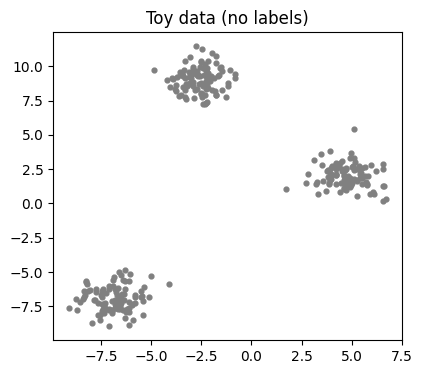

In [2]:
X_toy, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.9, random_state=42)
print(X_toy.shape)
plt.figure(figsize=(4.5, 4))
plt.scatter(X_toy[:, 0], X_toy[:, 1], s=12, color="gray")
plt.title("Toy data (no labels)")
plt.show()

下面兩個函式就是 K-Means 的全部核心：

- `assign`（分配）：每個點找距離最近的群中心（centroid）
- `update`（更新）：每個群中心搬到自己成員的平均位置

只要反覆做這兩步，直到群中心不再移動。

iteration 1: centers moved 6.620
iteration 2: centers moved 0.376
iteration 3: centers moved 0.497
iteration 4: centers moved 1.106
iteration 5: centers moved 5.433
iteration 6: centers moved 5.937
iteration 7: centers moved 0.000
converged, cluster sizes: [100 100 100]


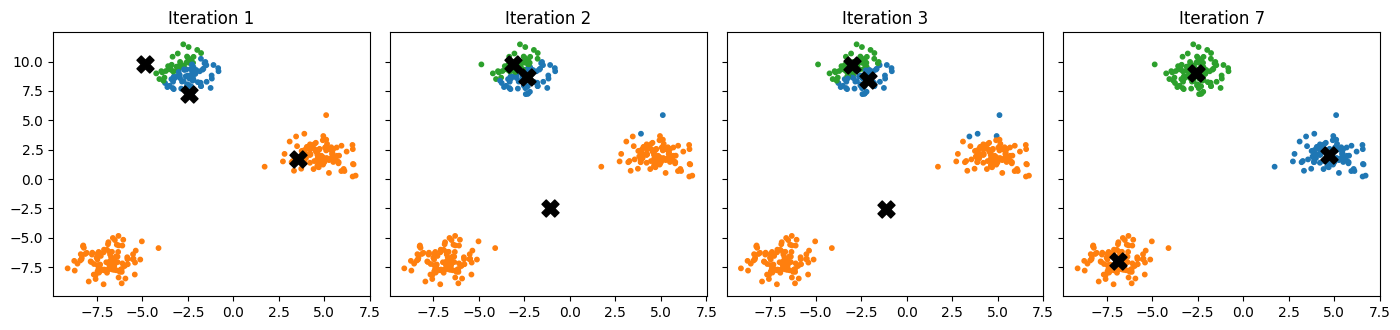

In [3]:
def assign(X, centers):
    # distance from every point to every center: shape (n_points, k)
    d = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
    return d.argmin(axis=1)

def update(X, labels, k):
    return np.array([X[labels == j].mean(axis=0) for j in range(k)])

rng = np.random.default_rng(6)
k = 3
centers = X_toy[rng.choice(len(X_toy), size=k, replace=False)]   # step 1: pick k random points as initial centers

snapshots = []
for it in range(1, 21):
    labels = assign(X_toy, centers)                                 # step 2: assign
    snapshots.append((it, labels, centers))
    new_centers = update(X_toy, labels, k)                          # step 3: update
    shift = np.linalg.norm(new_centers - centers)
    print(f"iteration {it}: centers moved {shift:.3f}")
    centers = new_centers
    if shift < 1e-6:                                                # step 4: repeat until nothing moves
        print("converged, cluster sizes:", np.bincount(labels))
        break

show = snapshots[:3] + [snapshots[-1]]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), sharex=True, sharey=True)
for ax, (it, labels, c) in zip(axes, show):
    ax.scatter(X_toy[:, 0], X_toy[:, 1], c=labels, cmap="tab10", vmin=0, vmax=9, s=10)
    ax.scatter(c[:, 0], c[:, 1], c="black", marker="X", s=150)
    ax.set_title(f"Iteration {it}")
plt.tight_layout()
plt.show()

前幾輪群中心會大幅移動，有時某個中心還會「跳」到另一團去；當移動距離變成 0，代表分配不再改變，也就是收斂了。最後每群 100 點，正好是資料產生時的三團。

## 2. 用 scikit-learn 做同一件事

實務上不用自己寫。`KMeans` 預設用 k-means++ 挑選比較分散的初始中心；`n_init=10` 代表用 10 組不同初始值各跑一次，留下最好的那次；`random_state` 固定讓結果可重現。

In [4]:
km_toy = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_toy)
print("cluster sizes:", np.bincount(km_toy.labels_))
print("inertia (within-cluster sum of squares):", round(km_toy.inertia_, 1))
print("silhouette:", round(silhouette_score(X_toy, km_toy.labels_), 3))

cluster sizes: [100 100 100]
inertia (within-cluster sum of squares): 459.2
silhouette: 0.863


`inertia_` 是「每個點到自己群中心距離平方的總和」，越小代表群越緊。輪廓係數（silhouette）介於 -1 到 1，越接近 1 代表群內緊、群間分得開；玩具資料的值會很高。記住這個數字，等一下跟真實病人資料比較。

## 3. 真實資料：Heart Failure Clinical Records

299 位心衰竭住院病人（巴基斯坦 Faisalabad 兩家醫院，2015 年），來源 UCI Machine Learning Repository（ID 519，CC BY 4.0）。原始研究：Ahmad T, et al. *PLoS One* 2017;12:e0181001；Chicco D, Jurman G. *BMC Med Inform Decis Mak* 2020;20:16。

先試 UCI 的 CSV 直連；失敗再改用 `ucimlrepo`（Colab 需先 `%pip install ucimlrepo`）。

In [5]:
URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/00519/"
       "heart_failure_clinical_records_dataset.csv")
try:
    df = pd.read_csv(URL)
except Exception as e:
    print("Direct CSV download failed:", e)
    try:
        from ucimlrepo import fetch_ucirepo
        r = fetch_ucirepo(id=519)
        df = r.data.features.join(r.data.targets)
    except Exception as e2:
        raise RuntimeError(
            "Cannot download the Heart Failure dataset. Check the internet connection, "
            "or run `%pip install ucimlrepo` and retry."
        ) from e2
df.columns = df.columns.str.lower()
print(df.shape)
df.head()

(299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


我們只拿 6 個**連續變數**來分群，`death_event`（追蹤期間是否死亡）先藏起來，最後才拿出來對照。二元變數（貧血、糖尿病、性別⋯⋯）只有 0/1 兩個值，用「距離」衡量不太合理，本章先不放進去。`time`（追蹤天數）跟結果綁在一起，也不放。

In [6]:
cols = ["age", "creatinine_phosphokinase", "ejection_fraction",
        "platelets", "serum_creatinine", "serum_sodium"]
df[cols].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.83,11.89,40.0,51.0,60.0,70.0,95.0
creatinine_phosphokinase,299.0,581.84,970.29,23.0,116.5,250.0,582.0,7861.0
ejection_fraction,299.0,38.08,11.83,14.0,30.0,38.0,45.0,80.0
platelets,299.0,263358.03,97804.24,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.39,1.03,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.63,4.41,113.0,134.0,137.0,140.0,148.0


注意兩件事：
1. 各變數的**單位與數量級差很多**：platelets 是幾十萬，serum_creatinine 只有 1 左右。
2. creatinine_phosphokinase（CPK）與 serum_creatinine **右偏很嚴重**（最大值是中位數的好幾倍）。

### 3.1 故意做錯：不標準化直接分群

K-Means 用的是歐氏距離，數字大的變數會主導距離。先看看直接丟原始數值會怎樣。

In [7]:
km_raw = KMeans(n_clusters=3, n_init=10, random_state=42).fit(df[cols])
print(df.assign(cluster=km_raw.labels_).groupby("cluster")["platelets"]
        .agg(["size", "min", "max"]))

         size       min       max
cluster                          
0         184  210000.0  338000.0
1          45  348000.0  850000.0
2          70   25100.0  208000.0


三群的血小板範圍幾乎**完全不重疊**：演算法其實只是按血小板數切成低、中、高三段，其他五個變數幾乎沒發言權。這不是醫學發現，而是單位造成的假象。

### 3.2 正確做法：偏態變數取對數，再標準化

CPK 與肌酸酐先取 log 壓縮長尾（減少極端值拉走群中心），再用 `StandardScaler` 把每個變數轉成平均 0、標準差 1。

In [8]:
X = df[cols].copy()
X["creatinine_phosphokinase"] = np.log(X["creatinine_phosphokinase"])
X["serum_creatinine"] = np.log(X["serum_creatinine"])
X_scaled = StandardScaler().fit_transform(X)
print(X_scaled.mean(axis=0).round(2) + 0.0)   # + 0.0 turns -0.0 into 0.0
print(X_scaled.std(axis=0).round(2))

[0. 0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1. 1.]


每一欄平均都變成 0、標準差都變成 1，六個變數現在站在同一個起跑點。

### 3.3 要分幾群？手肘法與輪廓係數

K 要事先指定。把 K 從 2 試到 8，記錄 inertia（手肘法，elbow method）與平均輪廓係數。

 k  inertia  silhouette
 2   1514.4       0.181
 3   1336.3       0.152
 4   1208.8       0.137
 5   1104.7       0.147
 6   1021.2       0.145
 7    947.0       0.160
 8    899.2       0.156


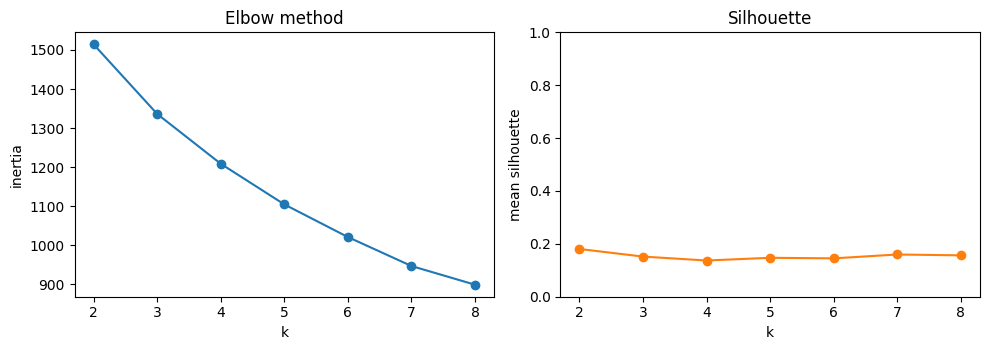

In [9]:
ks = range(2, 9)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_))

print(pd.DataFrame({"k": list(ks),
                    "inertia": [round(v, 1) for v in inertias],
                    "silhouette": [round(v, 3) for v in sils]}).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(list(ks), inertias, "o-")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia"); axes[0].set_title("Elbow method")
axes[1].plot(list(ks), sils, "o-", color="tab:orange")
axes[1].set_xlabel("k"); axes[1].set_ylabel("mean silhouette"); axes[1].set_title("Silhouette")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

跟玩具資料比，這裡的手肘**不明顯**，輪廓係數在每個 K 都低於 0.2——代表這群病人並沒有「涇渭分明的天然群」，比較像一片連續分布。這在真實臨床資料很常見。

K=2 的輪廓係數最高，但差距很小；為了示範多一點亞群的樣貌，下面用 K=3（K=2 留給你當練習）。這是一個**需要說清楚理由的主觀選擇**，不是演算法算出的標準答案。

### 3.4 K=3 分群與各群輪廓

In [10]:
km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_scaled)
df["cluster"] = km.labels_
print("cluster sizes:", df["cluster"].value_counts().sort_index().to_dict())
profile = df.groupby("cluster")[cols].median().round(2)
profile

cluster sizes: {0: 69, 1: 151, 2: 79}


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium
cluster,,,,,,
0,65.0,246.0,30.0,243000.00,1.83,134.0
1,53.0,478.0,35.0,263358.03,1.00,138.0
2,65.0,129.0,50.0,255000.00,1.10,138.0


用**原始單位的中位數**描述各群，比看標準化後的數字容易解讀。找找看：哪一群年紀較大、肌酸酐較高、血鈉較低、射出分率較低？

### 3.5 事後對照：各群死亡比例

分群時完全沒有用到 `death_event`。現在才把它拿出來，看各群在追蹤期間的死亡比例。

In [11]:
outcome = df.groupby("cluster")["death_event"].agg(n="size", deaths="sum", death_rate="mean")
outcome["death_rate"] = outcome["death_rate"].round(3)
outcome

,n,deaths,death_rate
cluster,,,
0,69,44,0.638
1,151,35,0.232
2,79,17,0.215


這是**描述性**的比較：
- 各群本來就是依肌酸酐、射出分率等變數劃分的，而這些變數本身就和預後有關，看到死亡比例不同並不意外。
- 這是巴基斯坦 Faisalabad 兩家醫院、299 人的觀察性資料，**不能**解讀為「屬於某群導致死亡」，也不代表這三群是真實存在的疾病亞型。
- 要主張某種分群有臨床價值，需要在其他醫院的資料重現（外部驗證），並確認它比既有的評估方式提供更多資訊。

本例僅供學習，不構成臨床建議。

### 3.6 分群穩不穩？換個亂數種子試試

用 `n_init=1`（只跑一組初始值）與 `n_init=10`，各換 10 個 `random_state`，用調整蘭德指數（adjusted Rand index, ARI；1 = 分群完全相同）比較結果和第一次有多像。

In [12]:
for n_init in [1, 10]:
    runs = [KMeans(n_clusters=3, n_init=n_init, random_state=s).fit(X_scaled) for s in range(10)]
    ari = [adjusted_rand_score(runs[0].labels_, r.labels_) for r in runs[1:]]
    inert = [r.inertia_ for r in runs]
    print(f"n_init={n_init:2d}: ARI vs first run  min={min(ari):.2f}  median={np.median(ari):.2f}; "
          f"inertia range {min(inert):.1f}-{max(inert):.1f}")

n_init= 1: ARI vs first run  min=0.22  median=0.47; inertia range 1336.0-1418.9


n_init=10: ARI vs first run  min=0.46  median=0.94; inertia range 1335.7-1337.8


只跑一組初始值時，換個種子結果就可能差很多；`n_init=10` 會穩定許多，但在結構不明顯的資料上仍不一定完全相同。報告分群結果時，應該附上穩定性檢查。

## 4. K-Means 的限制：非球形的群

K-Means 假設每一群大致是「圓的一團」。兩個互相咬合的半月形就會分錯。

agreement with true shapes (ARI): 0.25


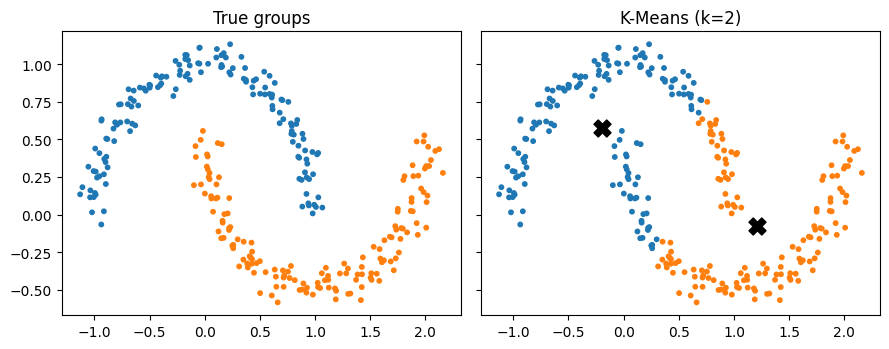

In [13]:
X_moon, y_moon = make_moons(n_samples=300, noise=0.06, random_state=42)
km_moon = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_moon)
print("agreement with true shapes (ARI):", round(adjusted_rand_score(y_moon, km_moon.labels_), 2))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True)
axes[0].scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap="tab10", vmin=0, vmax=9, s=10)
axes[0].set_title("True groups")
axes[1].scatter(X_moon[:, 0], X_moon[:, 1], c=km_moon.labels_, cmap="tab10", vmin=0, vmax=9, s=10)
axes[1].scatter(*km_moon.cluster_centers_.T, c="black", marker="X", s=150)
axes[1].set_title("K-Means (k=2)")
plt.tight_layout()
plt.show()

K-Means 把平面從中間切一刀，而不是沿著兩個月牙的形狀分。這類資料要改用 DBSCAN 或階層式分群（hierarchical clustering）等方法。

## 5. 動手試試

1. 把 3.4 的 `n_clusters=3` 改成 `2`，重跑 3.4 與 3.5：兩群的樣貌與死亡比例怎麼變？
2. 在 3.2 拿掉取對數那兩行（只標準化），重跑 3.3 到 3.5：輪廓係數與各群輪廓有什麼改變？
3. 在第 1 節把 `np.random.default_rng(6)` 的 6 改成 0，重跑：最後各群人數是不是還是 100／100／100？這就是「初始值不好、卡在局部最佳解」。再和第 2 節 `KMeans(n_init=10)` 的結果比較。